# 4.2.1 均方误差

In [2]:
import numpy as np

def mean_squared_err(y, t):
    return 0.5 * np.sum((y - t) ** 2)

# 4.2.2 交叉熵误差

In [3]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return np.sum(t * np.log(y + delta))

t = [0, 0, 1]
y = [0.1, 0.05, 0.6]
print(cross_entropy_error(np.array(y), np.array(t)))

-0.510825457099338


# 4.2.3 mini-batch

In [4]:
import sys, os

sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(x_train.shape)
print(t_train.shape)

train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
# print(x_batch)
# print(t_batch)

(60000, 784)
(60000, 10)


# 4.3 数值微分

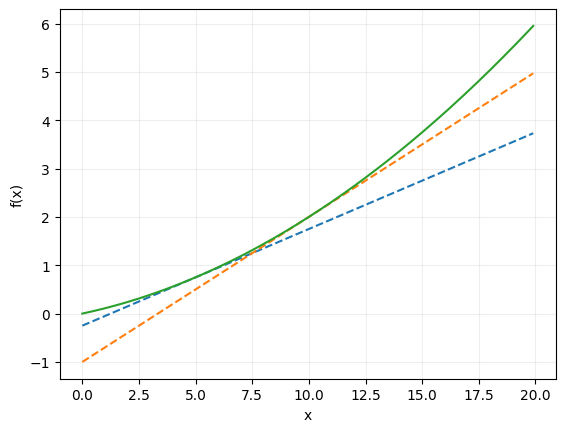

In [5]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2*h)

def function_1(x):
    return 0.01*x**2 + 0.1*x

import numpy as np
from matplotlib import pyplot as plt

# 计算x=5和x=10的导数
def line_5(x):
    diff_5 = numerical_diff(function_1, 5)
    b_5 = function_1(5) - diff_5 * 5
    return diff_5 * x + b_5

def line_10(x):
    diff_10 = numerical_diff(function_1, 10)
    b_10 = function_1(10) - diff_10 * 10
    return diff_10 * x + b_10

plt.xlabel("x")
plt.ylabel("f(x)")

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

# x=5的切线
plt.plot(x, line_5(x), '--', label="x=5")
# x=10的切线
plt.plot(x, line_10(x), '--', label="x=10")

plt.plot(x, y)
plt.grid(True, alpha=0.2)
plt.show()

# 4.3.3 偏导数

In [6]:
def function_2(x):
    return x[0]**2 + x[1]**2

def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x)
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)
        x[idx] = tmp_val - h
        fxh2 = f(x)

        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
    return grad

print(numerical_gradient(function_2, np.array([3.0, 4.0])))
print(numerical_gradient(function_2, np.array([0.0, 2.0])))
print(numerical_gradient(function_2, np.array([3.0, 0.0])))

[6. 8.]
[0. 4.]
[6. 0.]


# 4.4.1 梯度法

In [7]:
def gradient_descent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr=0.1, step_num=1000)

array([-5.65129794e-21,  4.96308368e-21])

# 神经网络的梯度

In [3]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3)

    def predict(self, x):
        return np.dot(x, self.W)

    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss
    
net = simpleNet()
print(net.W)

x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)
t = np.array([0, 0, 1])
print(net.loss(x, t))

def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.77108905  0.71076703  1.30793701]
 [-0.30606918 -1.31614137  2.37250255]]
[ 0.18719117 -0.75806701  2.9200145 ]
0.08645903826572476
[[ 0.03578923  0.01390695 -0.04969618]
 [ 0.05368385  0.02086043 -0.07454428]]


# 4.5.1 2层神经网络的类

In [2]:
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
from common.functions import *
from common.gradient import numerical_gradient


class TwoLayerNet:

    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        # 初始化权重
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
    
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        return y
        
    # x:输入数据, t:监督数据
    def loss(self, x, t):
        y = self.predict(x)
        
        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        t = np.argmax(t, axis=1)
        
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
    
      # x:输入数据, t:监督数据
    def numerical_gradient(self, x, t):
        loss_W = lambda W: self.loss(x, t)
        
        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])
        
        return grads
    
    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}
        
        batch_num = x.shape[0]
        
        # forward
        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)
        
        # backward
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)
        
        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads
    
net = TwoLayerNet(784, 50, 10)
net.params['W1'].shape
net.params['b1'].shape
net.params['W2'].shape
net.params['b2'].shape

x = np.random.rand(100, 784)
y = net.predict(x)
# print(y)

x = np.random.rand(100, 784)
t = np.random.rand(100, 10)

# grads = net.numerical_gradient(x, t)
grads = net.gradient(x, t)

print(grads['W1'].shape)
print(grads['b1'].shape)
print(grads['W2'].shape)
print(grads['b2'].shape)

(784, 50)
(50,)
(50, 10)
(10,)


# 4.5.2 mini-batch的实现

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
train acc, test acc | 0.10318333333333334, 0.1072
train acc, test acc | 0.7968333333333333, 0.8001
train acc, test acc | 0.8772166666666666, 0.8804
train acc, test acc | 0.8983666666666666, 0.9015
train acc, test acc | 0.909, 0.9118
train acc, test acc | 0.9155333333333333, 0.9167
train acc, test acc | 0.9201666666666667, 0.9203
train acc, test acc | 0.9245666666666666, 0.9263
train acc, test acc | 0.9287833333333333, 0.9293
train acc, test acc | 0.9326, 0.9331
train acc, test acc | 0.9357166666666666, 0.9362
train acc, test acc | 0.9384833333333333, 0.9379
train acc, test acc | 0.9407, 0.9416
train acc, test acc | 0.9421833333333334, 0.9432
train acc, test acc | 0.9445333333333333, 0.9452
train acc, test acc | 0.9469666666666666, 0.9465
train acc, test acc | 0.9483833333333334, 0.947


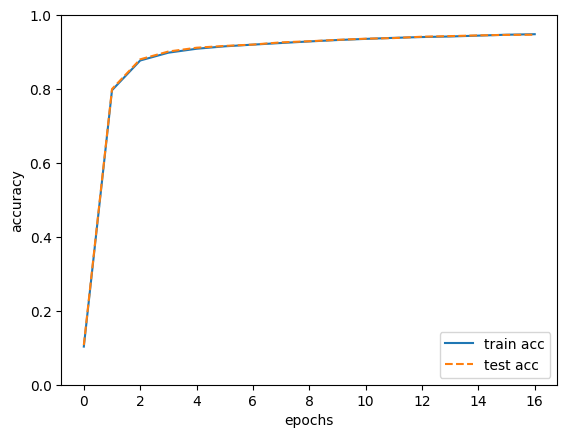

In [8]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from book_code.ch04.two_layer_net import TwoLayerNet

# 读入数据
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(t_train)


network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000  # 适当设定循环的次数
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 计算梯度
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)
    
    # 更新参数
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# 绘制图形
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


# 4.5.3 基于测试数据的评价

In [ ]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from book_code.ch04.two_layer_net import TwoLayerNet

# 读入数据
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(t_train)


network = TwoLayerNet(input_size=784, hidden_size=50, output_size=10)

iters_num = 10000  # 适当设定循环的次数
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.1

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)

print(iter_per_epoch)

for i in range(iters_num):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    # 计算梯度
    #grad = network.numerical_gradient(x_batch, t_batch)
    grad = network.gradient(x_batch, t_batch)
    
    # 更新参数
    for key in ('W1', 'b1', 'W2', 'b2'):
        network.params[key] -= learning_rate * grad[key]
    
    loss = network.loss(x_batch, t_batch)
    train_loss_list.append(loss)
    
    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))

# 绘制图形
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, label='train acc')
plt.plot(x, test_acc_list, label='test acc', linestyle='--')
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
600.0
train acc, test acc | 0.09915, 0.1009
train acc, test acc | 0.7828166666666667, 0.787
train acc, test acc | 0.87515, 0.8785
train acc, test acc | 0.8980166666666667, 0.9024
train acc, test acc | 0.9072, 0.9095
train acc, test acc | 0.9137666666666666, 0.9154
train acc, test acc | 0.9195166666666666, 0.922
train acc, test acc | 0.9238, 0.9269
train acc, test acc | 0.9277, 0.9304
train acc, test acc | 0.93095, 0.9319
train acc, test acc | 0.9338, 0.9343
train acc, test acc | 0.936, 0.9367
train acc, test acc | 0.9385833333333333, 0.9377
train acc, test acc | 0.9411333333333334, 0.9388
train acc, test acc | 0.9431, 0.9413
train acc, test acc | 0.94495, 0.9432
train acc, test acc | 0.94755, 0.9455
